# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 07: MLP e CNN**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_07_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [1]:
!pip install tensorflow numpy matplotlib seaborn scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)
np.random.seed(42)

# <font color='green'><u><b>Parte 1 - Conjunto de Dados</b></u></font>

Não altere o conteúdo da célula a seguir!

In [3]:
# Carregando o dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Ajustando dimensões dos rótulos
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

# Separando validação do treino
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Classes do dataset
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 34s 0us/step


### <font color='#2D9CDB'>Q1) O dataset CIFAR-10 é amplamente utilizado em problemas de visão computacional e classificação de imagens. Pesquise brevemente sobre o dataset e descreva, em um único parágrafo, o domínio de aplicação da base de dados, o objetivo para o qual ela foi criada, o tipo de imagens que ela contém, a quantidade de classes existentes e alguns exemplos de objetos presentes nas imagens.</font>

O CIFAR-10 foi desenvolvido em 2009 por pesquisadores da Universidade de Toronto, como um subconjunto do Tiny Images Dataset, com o objetivo de avaliar modelos de aprendizado profundo e servir como referência em pesquisas de classificação e reconhecimento de objetos. As imagens são simples e representam objetos comuns do cotidiano, organizados em 10 classes balanceadas: avião, automóvel, pássaro, gato, cervo, cachorro, sapo, cavalo, navio e caminhão. Cada classe possui 6.000 imagens, e o dataset é amplamente utilizado para testar arquiteturas de redes neurais convolucionais (CNNs) e outros algoritmos de aprendizado de máquina, justamente por sua simplicidade e padronização.

### <font color='#2D9CDB'>Q2) Exiba as dimensões dos conjuntos de treinamento, validação e teste, o formato das imagens, as dimensões dos vetores de rótulos e os valores únicos da variável alvo. Com base nos resultados obtidos, responda quantas imagens existem nos conjuntos de treinamento, validação e teste, qual é a resolução das imagens, quantos canais cada imagem possui e quantas classes diferentes existem no dataset.</font>

In [4]:
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)
print("Formato de uma imagem: ", x_train[0].shape)
print("Formato dos vetores de rótulos: ", y_train.shape)
print("Valores únicos da variável alvo: ", np.unique(y_train))

(40000, 32, 32, 3)
(10000, 32, 32, 3)
(10000, 32, 32, 3)
Formato de uma imagem:  (32, 32, 3)
Formato dos vetores de rótulos:  (40000,)
Valores únicos da variável alvo:  [0 1 2 3 4 5 6 7 8 9]


* Treinamento: 40.000 imagens
* Validação: 10.000 imagens
* Teste: 10.000 imagens
* Resolução: 32 × 32 pixels
* Canais: 3 (RGB)
* Classes: 10

### <font color='#2D9CDB'>Q3) Plote as primeiras 25 imagens do conjunto de treinamento utilizando a função imshow, exibindo também o nome da classe correspondente a cada imagem. Organize as imagens em uma grade 5×5 e remova os eixos para melhorar a visualização. Em seguida, analise visualmente o dataset e discuta se as imagens parecem simples ou complexas para classificação, quais características tornam o problema mais desafiador e se existem classes visualmente semelhantes.</font>

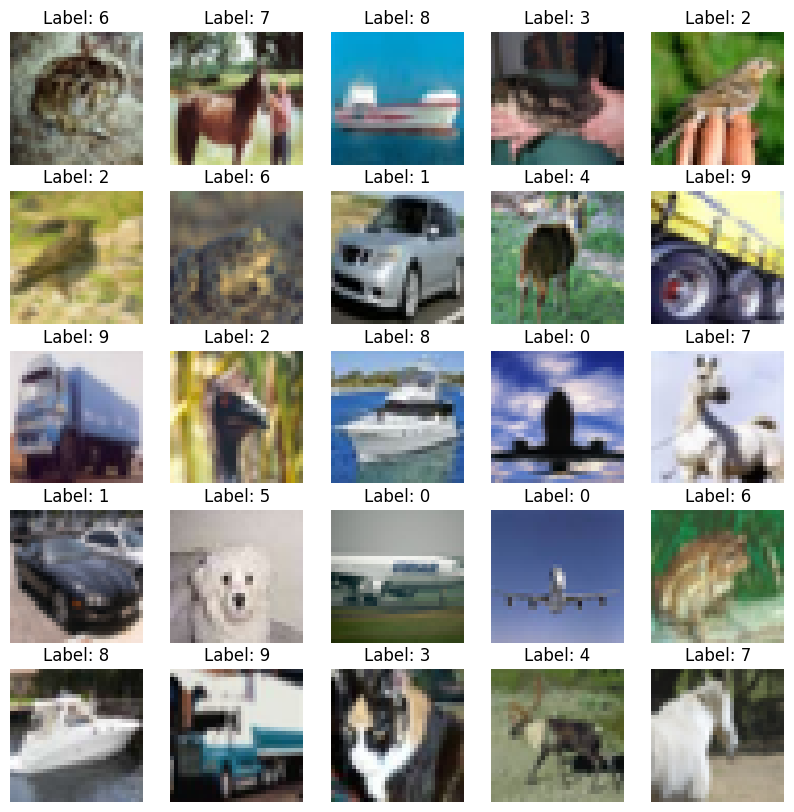

In [5]:
plt.figure(figsize=(10,10))  # size of the figure

for i in range(25):
    plt.subplot(5,5,i+1)    # create a grid with 5 rows and 5 columns
    plt.imshow(x_train[i], cmap='gray')  # show image
    plt.title("Label: {}".format(y_train[i]))  # show the true digit
    plt.axis('off')  # remove axis for better visualization

plt.show()

  As imagens são pequenas (32×32 pixels) e de baixa resolução, o que torna a classificação mais desafiadora, pois muitos detalhes se perdem.

  As classes incluem objetos simples e comuns (avião, carro, gato, cachorro, etc.), mas alguns são visualmente semelhantes: por exemplo, cachorro vs. gato, ou caminhão vs. automóvel, o que pode confundir o modelo.
  
  O fundo das imagens varia bastante, adicionando ruído visual que dificulta a identificação.

### <font color='#2D9CDB'>Q4) Plote a distribuição das classes do conjunto de treinamento utilizando um gráfico de barras. Com base no gráfico obtido, analise se o dataset é balanceado ou desbalanceado, compare a quantidade de amostras entre as classes e discuta se o balanceamento das classes pode impactar o treinamento e o desempenho de uma rede neural.</font>

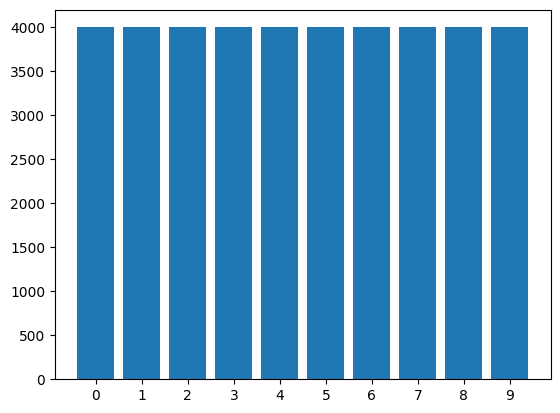

In [6]:
classes, counts = np.unique(y_train, return_counts=True)
plt.bar(classes, counts)
plt.xticks(classes)
plt.show()

O CIFAR-10 é balanceado: cada classe tem aproximadamente 4.000 imagens no conjunto de treinamento.

O balanceamento é importante porque evita que a rede neural aprenda com viés para classes majoritárias.

### <font color='#2D9CDB'>Q5) Verifique os valores mínimo e máximo dos pixels das imagens do conjunto de treinamento. Em seguida, normalize os conjuntos de treino, validação e teste dividindo os valores dos pixels por 255. Após a normalização, verifique novamente os valores mínimo e máximo e explique por que esse procedimento é importante para o treinamento de redes neurais profundas. Discuta também como a normalização influencia a estabilidade numérica do treinamento e a velocidade de convergência do algoritmo de otimização.</font>

In [7]:
print("antes da normalização:")
print(x_train.max())
print(x_train.min())

# normalizar
x_train = x_train / 255.0
x_test = x_test / 255.0
x_val   = x_val / 255.0

print("depois da normalização:")
print(x_train.max())
print(x_train.min())

antes da normalização:
255
0
depois da normalização:
1.0
0.0


Esse procedimento é fundamental para o treinamento de redes neurais profundas porque melhora a estabilidade numérica, evitando problemas como gradientes explosivos ou muito pequenos, e acelera a convergência do algoritmo de otimização, já que os pesos da rede são ajustados de forma mais consistente. Além disso, funções de ativação como sigmoid, tanh e ReLU funcionam melhor quando os dados estão normalizados, permitindo que o modelo aprenda padrões mais rapidamente e com maior precisão.

### <font color='#2D9CDB'>Q6) Explique por que as imagens do CIFAR-10 podem ser representadas como tensores tridimensionais. Em seguida, identifique o significado de cada dimensão do tensor (32, 32, 3), explique o papel dos canais RGB e discuta a diferença entre imagens coloridas e imagens em tons de cinza no contexto de redes neurais convolucionais.</font>

As imagens do CIFAR-10 são representadas como tensores tridimensionais porque possuem altura, largura e canais de cor. O formato (32, 32, 3) indica 32 pixels de altura, 32 de largura e 3 canais correspondentes ao RGB (vermelho, verde e azul), que juntos formam as cores da imagem. Os canais permitem que a rede capture informações cromáticas, enquanto imagens em tons de cinza têm apenas um canal de intensidade luminosa. Assim, imagens coloridas oferecem mais riqueza de informação, mas aumentam a complexidade do modelo, enquanto imagens em cinza são mais simples de processar, porém podem perder detalhes importantes quando a cor é relevante para distinguir classes.

# <font color='green'><u><b>Parte 2 - MLP</b></u></font>

### <font color='#2D9CDB'>Q7) As redes neurais do tipo Multilayer Perceptron (MLP) utilizam camadas densamente conectadas e, portanto, esperam vetores unidimensionais como entrada. Explique por que é necessário transformar as imagens do CIFAR-10 antes de utilizá-las em uma MLP e discuta o que acontece com a estrutura espacial das imagens durante esse processo. Em seguida, construa uma rede neural MLP utilizando a API Sequential do Keras com uma camada Flatten, duas camadas densas escondidas com função de ativação ReLU e uma camada de saída com 10 neurônios e ativação Softmax.</font>

In [8]:
model = keras.Sequential(
    [
      layers.Input(shape=(32, 32, 3)),

      layers.Flatten(),

      layers.Dense(512, activation='relu'),

      layers.Dense(256, activation='relu'),

      # Camada de saída
      # 10 neurônios → um para cada classe (0 a 9)
      # Softmax transforma a saída em probabilidades
      layers.Dense(10, activation='softmax')
    ]
)

O CIFAR-10 possui imagens de dimensão 32 × 32 × 3, ou seja, uma matriz tridimensional. As MLPs trabalham apenas com vetores unidimensionais. Por isso, é necessário aplicar uma camada Flatten, que transforma cada imagem em um vetor.

### <font color='#2D9CDB'>Q8) Exiba o resumo da arquitetura da rede neural criada utilizando o método summary() e analise a quantidade de parâmetros treináveis da MLP. Com base nas dimensões das imagens do CIFAR-10 e no número de neurônios utilizados nas camadas densas, discuta por que MLPs podem rapidamente se tornar modelos muito grandes para problemas de classificação de imagens.</font>

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

A primeira camada densa já possui mais de 1,5 milhão de parâmetros, pois conecta 3072 entradas a 512 neurônios.

Isso mostra que MLPs podem crescer rapidamente em número de parâmetros quando aplicadas a imagens, tornando-se modelos muito grandes e propensos a overfitting.

### <font color='#2D9CDB'>Q9) Compile a MLP utilizando o otimizador Adam com taxa de aprendizado de $10^{-3}$, a função de custo sparse_categorical_crossentropy e a métrica accuracy. Em seguida, explique o papel da função de custo durante o treinamento, o objetivo do algoritmo de otimização e por que a combinação entre Softmax e entropia cruzada é adequada para problemas de classificação multiclasse.</font>

In [10]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Função de custo: mede a discrepância entre as previsões do modelo e os rótulos reais, guiando o aprendizado.

Otimizador Adam: ajusta os pesos para minimizar a função de custo, combinando momentum e adaptação da taxa de aprendizado.

Softmax gera probabilidades para cada classe. Entropia cruzada penaliza fortemente previsões incorretas. Essa combinação é ideal para classificação multiclasse.

### <font color='#2D9CDB'>Q10) Treine a rede neural por 25 épocas utilizando os conjuntos de treinamento e validação. Armazene o histórico do treinamento em um objeto do tipo History e, em seguida, plote gráficos mostrando a evolução da loss e da accuracy ao longo das épocas para os conjuntos de treinamento e validação. Após gerar os gráficos, analise o comportamento do treinamento, discutindo se o modelo aparenta convergir adequadamente, se há estabilidade durante o treinamento e se existem indícios de overfitting.</font>

Epoch 1/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3210 - loss: 1.8789 - val_accuracy: 0.3345 - val_loss: 1.8514
Epoch 2/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3857 - loss: 1.7014 - val_accuracy: 0.4030 - val_loss: 1.6706
Epoch 3/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4193 - loss: 1.6154 - val_accuracy: 0.4220 - val_loss: 1.6342
Epoch 4/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4439 - loss: 1.5535 - val_accuracy: 0.4296 - val_loss: 1.6185
Epoch 5/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4607 - loss: 1.5115 - val_accuracy: 0.4413 - val_loss: 1.5741
Epoch 6/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4745 - loss: 1.4795 - val_accuracy: 0.4456 - val_loss: 1.5888
Epoch 7/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4818 - loss: 1.4546 - val_accuracy: 0.4667 - val_loss: 1.5300
Epoch 8/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4902 - loss: 1.4327 - 

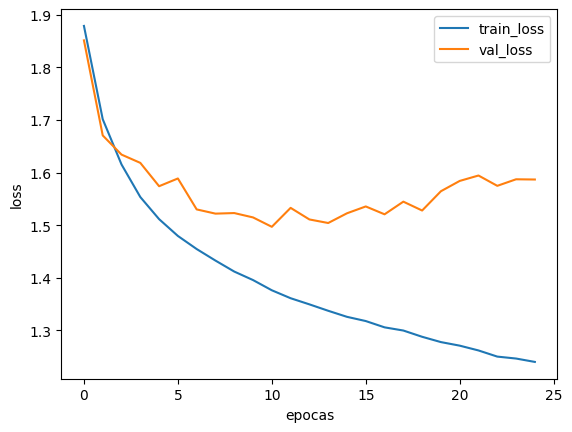

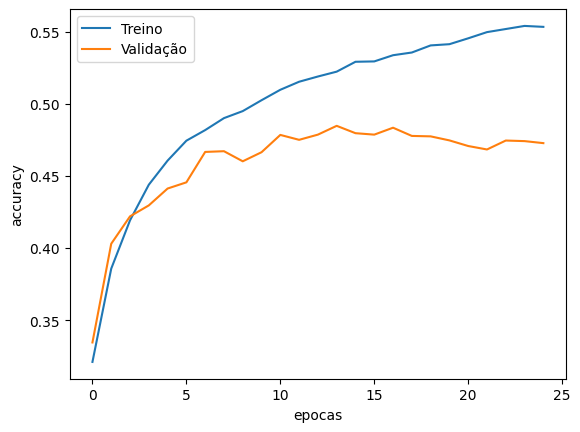

In [11]:
history = model.fit(
    x_train,
    y_train,
    epochs=25,
    batch_size=32,
    validation_data=(x_val, y_val)
)

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('epocas')
plt.ylabel('loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.xlabel('epocas')
plt.ylabel('accuracy')
plt.legend()
plt.show()

O modelo está de fato aprendendo, pois a loss de treino diminui e a accuracy aumenta de forma estável.
  
A val_loss não segue uma curva suave, indicando que o modelo pode estar começando a sobreajustar (overfitting).

A diferença entre accuracy de treino e validação não é enorme, mas já mostra uma tendência de overfitting.

O modelo aprende e converge, mas apresenta sinais de overfitting moderado e limitações de generalização.

### <font color='#2D9CDB'>Q11) Avalie o desempenho da MLP utilizando o conjunto de teste e reporte os valores de loss e accuracy obtidos. Em seguida, compare os resultados dos conjuntos de treinamento e teste e discuta se o modelo aparenta apresentar boa capacidade de generalização.</font>

In [13]:
mlp_test_loss, mlp_test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"loss no teste: {mlp_test_loss:.4f}")
print(f"acurácia no teste: {mlp_test_acc:.4f}")

313/313 - 1s - 4ms/step - accuracy: 0.4678 - loss: 1.5667
loss no teste: 1.5667
acurácia no teste: 0.4678


O modelo apresenta aprendizado consistente e generalização aceitável, mas limitado. A MLP atinge cerca de 47% de acurácia no teste, o que é insuficiente para aplicações práticas em visão computacional.

### <font color='#2D9CDB'>Q12) Utilize a MLP treinada para gerar previsões sobre algumas imagens do conjunto de teste. Exiba as probabilidades previstas para cada classe, identifique a classe predita pelo modelo e compare-a com a classe verdadeira da imagem. Com base nas probabilidades obtidas, explique o significado da saída Softmax e discuta se o modelo está realizando previsões com alta ou baixa confiança.</font>

In [14]:
sample_images = x_test[:5]
sample_labels = y_test[:5]

predictions = model.predict(sample_images)

for i in range(len(sample_images)):
    print(f"imagem {i+1}")
    print("probabilidades por classe:", predictions[i])
    predicted_class = np.argmax(predictions[i])
    print(f"classe predita: {predicted_class}")
    print(f"classe verdadeira: {sample_labels[i]}")
    print("\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
imagem 1
probabilidades por classe: [3.46971080e-02 1.63227972e-02 4.71888576e-03 6.11025214e-01
 3.28862248e-03 9.91637632e-03 2.28002129e-04 2.14995727e-01
 9.41835940e-02 1.06236935e-02]
classe predita: 3
classe verdadeira: 3


imagem 2
probabilidades por classe: [5.02648056e-02 5.15141666e-01 2.43386501e-04 1.11558424e-04
 2.29487283e-04 1.17594273e-05 4.50187963e-06 3.77660122e-04
 1.99313730e-01 2.34301493e-01]
classe predita: 1
classe verdadeira: 8


imagem 3
probabilidades por classe: [1.0043509e-01 3.8441472e-02 1.8043669e-03 8.1408974e-03 1.2768890e-02
 3.6521363e-03 1.2616318e-04 1.4003889e-02 4.5371217e-01 3.6691493e-01]
classe predita: 8
classe verdadeira: 8


imagem 4
probabilidades por classe: [0.2327908  0.04409491 0.06964664 0.05380624 0.0388764  0.03455758
 0.00178857 0.05207369 0.3945868  0.07777826]
classe predita: 8
classe verdadeira: 0


imagem 5
probabilidades por classe: [2.0160051e-03 6.4112578e-04 1.9039074e-01 8.4025890e

A saída Softmax fornece não apenas a classe escolhida, mas também o grau de confiança da previsão.

A MLP acerta algumas imagens com confiança alta, mas em outras demonstra incerteza, refletindo sua limitação em capturar padrões visuais complexos.

Isso explica por que a acurácia geral no CIFAR-10 ficou em torno de 49%: o modelo consegue aprender alguns padrões, mas erra quando as classes são visualmente semelhantes ou quando não há confiança clara.

### <font color='#2D9CDB'>Q13) Plote a matriz de confusão da MLP utilizando o conjunto de teste. Em seguida, identifique quais classes foram mais confundidas pelo modelo e discuta possíveis razões para esses erros de classificação, considerando as limitações de uma arquitetura MLP aplicada a problemas de visão computacional.</font>

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


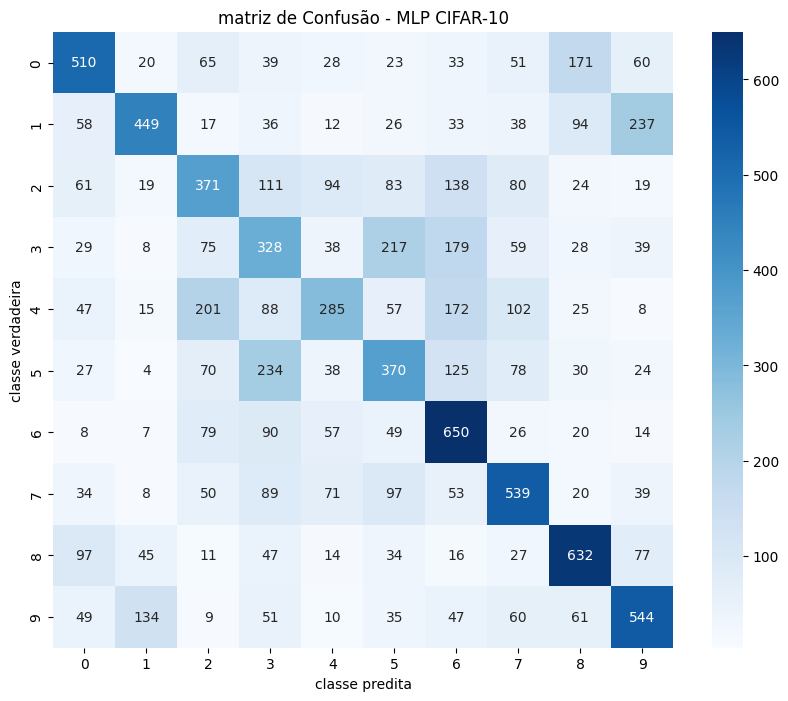

In [15]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("classe predita")
plt.ylabel("classe verdadeira")
plt.title("matriz de Confusão - MLP CIFAR-10")
plt.show()

A matriz de confusão evidencia que a MLP acerta melhor classes mais distintas (como navios e sapos), mas confunde fortemente classes visualmente semelhantes (gato/cachorro, cervo/cavalo, carro/caminhão).
Esses erros refletem a limitação estrutural da MLP em lidar com imagens, reforçando a necessidade de arquiteturas como CNNs para problemas de visão computacional.

### <font color='#2D9CDB'>Q14) Com base nos resultados obtidos ao longo desta etapa, discuta as principais vantagens e limitações das redes MLP para classificação de imagens. Em sua resposta, considere aspectos como preservação da estrutura espacial das imagens, quantidade de parâmetros treináveis, capacidade de generalização e desempenho obtido no CIFAR-10.</font>

Ao achatar as imagens em vetores, a MLP ignora a relação entre pixels vizinhos. Isso impede que o modelo capture padrões locais como bordas, texturas e formas, fundamentais para distinguir classes semelhantes.

Cada pixel é conectado a todos os neurônios da primeira camada densa. No CIFAR-10, isso gera milhões de parâmetros já nas primeiras camadas, aumentando o risco de overfitting e exigindo mais recursos computacionais.

Embora o modelo tenha aprendido, o desempenho no teste mostra que a generalização é apenas razoável. O gap entre treino e teste evidencia que o modelo memoriza parte dos dados sem capturar padrões robustos.

No CIFAR-10, que contém imagens coloridas e variadas, a MLP alcançou menos de 50% de acurácia. CNNs, por outro lado, conseguem superar facilmente 80–90% ao explorar convoluções e pooling.

As MLPs são úteis como introdução ao aprendizado profundo e funcionam bem em dados estruturados ou problemas simples.
No entanto, para classificação de imagens, suas limitações tornam o desempenho modesto:

* não preservam a estrutura espacial,

* têm muitos parâmetros,

* e generalizam pouco.

# <font color='green'><u><b>Parte 3 - CNN</b></u></font>

### <font color='#2D9CDB'>Q15) As redes neurais convolucionais (CNNs) foram desenvolvidas para lidar melhor com dados que possuem estrutura espacial, como imagens. Explique por que arquiteturas MLP apresentam limitações em problemas de visão computacional e descreva como as CNNs conseguem preservar relações espaciais entre os pixels. Em seguida, explique os conceitos de convolução, filtros convolucionais e mapas de características (feature maps).</font>

As redes neurais do tipo MLP apresentam dificuldades em lidar com problemas de visão computacional porque tratam cada pixel da imagem como uma entrada independente, sem considerar a relação espacial entre eles. Isso faz com que a rede não consiga identificar padrões locais, como bordas ou texturas, e também aumenta muito a quantidade de parâmetros quando se trabalha com imagens de alta resolução, tornando o treinamento mais caro e sujeito a overfitting.

As CNNs foram desenvolvidas justamente para superar essas limitações. Elas exploram a estrutura bidimensional das imagens por meio da aplicação de filtros locais que percorrem a matriz de pixels. Dessa forma, conseguem preservar as relações espaciais e aprender padrões visuais de maneira hierárquica: nas primeiras camadas detectam elementos simples como linhas e bordas, nas intermediárias reconhecem partes de objetos e, nas últimas, identificam objetos completos. Isso torna o aprendizado mais eficiente e escalável.

O conceito de convolução é central nesse processo. Trata-se de uma operação matemática em que um filtro, também chamado de kernel, é aplicado sobre pequenas regiões da imagem, produzindo valores que indicam a presença de determinado padrão. Esses filtros convolucionais são pequenas matrizes, como 3×3 ou 5×5, que aprendem automaticamente a detectar características específicas, como bordas horizontais ou texturas. O resultado da aplicação de um filtro sobre toda a imagem é chamado de mapa de características (feature map), que evidencia as regiões onde o padrão correspondente aparece. Esses mapas são combinados ao longo das camadas da rede, permitindo que a CNN construa representações cada vez mais complexas e abstratas da imagem.  

Assim, enquanto as MLPs ignoram a estrutura espacial dos dados, as CNNs aproveitam essa estrutura para aprender representações visuais mais ricas e eficazes.

### <font color='#2D9CDB'>Q16) Construa uma rede neural convolucional utilizando a API Sequential do Keras. A arquitetura da CNN deve conter camadas Conv2D com ativação ReLU, camadas MaxPooling2D, uma camada Flatten e uma camada de saída com 10 neurônios e ativação Softmax. Após construir a arquitetura, explique o papel das camadas convolucionais, das camadas de pooling e da camada Flatten dentro da CNN.</font>

In [16]:
model = keras.Sequential([
    # entrada: imagem 32x32 com 3 canais (RGB)
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])


As camadas convolucionais têm como função principal extrair características locais da imagem. Cada filtro convolucional percorre a matriz de pixels e aprende a identificar padrões específicos, como bordas, texturas ou formas simples. À medida que avançamos nas camadas, os filtros passam a reconhecer padrões mais complexos, como partes de objetos ou até mesmo objetos inteiros. A ativação ReLU é utilizada para introduzir não linearidade, permitindo que a rede aprenda representações mais sofisticadas.

As camadas de pooling, como o MaxPooling2D, reduzem a dimensão espacial da imagem ao selecionar apenas os valores mais relevantes em pequenas regiões. Isso diminui o número de parâmetros, reduz o custo computacional e ajuda a tornar o modelo mais robusto a pequenas variações, como deslocamentos ou ruídos na imagem. Em outras palavras, o pooling atua como uma forma de compressão que mantém as informações mais importantes.

A camada Flatten tem o papel de transformar a matriz bidimensional resultante das convoluções e pooling em um vetor unidimensional. Esse vetor pode então ser utilizado pelas camadas densas (fully connected), que realizam a classificação final. Sem o Flatten, não seria possível conectar diretamente os mapas de características às camadas densas, já que estas esperam entradas em formato de vetor.

Assim, a CNN combina convoluções para extrair padrões visuais, pooling para reduzir a complexidade e Flatten para preparar os dados para a etapa de classificação, resultando em uma arquitetura eficiente para problemas de visão computacional.

### <font color='#2D9CDB'>Q17) Exiba o resumo da arquitetura da CNN utilizando o método summary() e compare a quantidade de parâmetros treináveis da CNN com a da MLP construída anteriormente. Em seguida, discuta por que CNNs costumam ser mais eficientes para classificação de imagens, mesmo utilizando menos parâmetros treináveis.</font>

In [17]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,384,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,405,258 (5.36 MB)

 Trainable params: 1,405,258 (5.36 MB)

 Non-trainable params: 0 (0.00 B)

CNNs são mais eficientes para classificação de imagens porque aproveitam a estrutura espacial dos dados. Elas usam filtros que percorrem a imagem e capturam padrões locais, como bordas e texturas, construindo representações hierárquicas cada vez mais complexas. Além disso, o compartilhamento de pesos reduz drasticamente o número de parâmetros, já que o mesmo filtro é aplicado em toda a imagem. Isso diminui o custo computacional e melhora a generalização, tornando a rede mais robusta a variações e deslocamentos, mesmo com menos parâmetros treináveis.

### <font color='#2D9CDB'>Q18) Compile a CNN utilizando o otimizador Adam com taxa de aprendizado de $10^{-3}$, a função de custo sparse_categorical_crossentropy e a métrica accuracy. Em seguida, treine o modelo por até 25 épocas utilizando os conjuntos de treinamento e validação. Armazene o histórico do treinamento em um objeto do tipo History. Após o treinamento, plote gráficos mostrando a evolução da loss e da accuracy ao longo das épocas para os conjuntos de treinamento e validação e analise o comportamento do treinamento da CNN.</font>

Epoch 1/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4938 - loss: 1.4040 - val_accuracy: 0.6167 - val_loss: 1.0976
Epoch 2/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6418 - loss: 1.0205 - val_accuracy: 0.6627 - val_loss: 0.9856
Epoch 3/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7080 - loss: 0.8424 - val_accuracy: 0.6790 - val_loss: 0.9546
Epoch 4/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7591 - loss: 0.7033 - val_accuracy: 0.6803 - val_loss: 0.9830
Epoch 5/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8004 - loss: 0.5823 - val_accuracy: 0.6620 - val_loss: 1.0977
Epoch 6/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8328 - loss: 0.4831 - val_accuracy: 0.6447 - val_loss: 1.2399
Epoch 7/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8638 - loss: 0.3936 - val_accuracy: 0.6344 - val_loss: 1.3983
Epoch 8/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8926 - loss: 0.3087 -

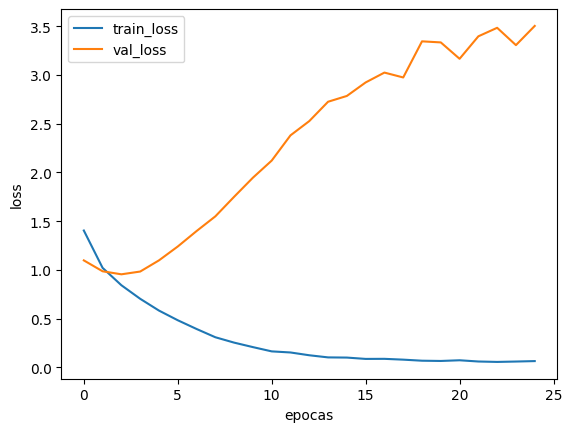

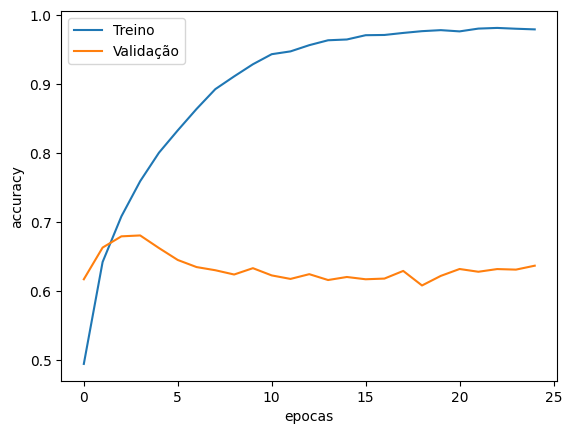

In [18]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=25,
    batch_size=32,
    validation_data=(x_val, y_val)
)

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('epocas')
plt.ylabel('loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.xlabel('epocas')
plt.ylabel('accuracy')
plt.legend()
plt.show()

O treinamento mostra que a CNN aprendeu bem os dados de treino, mas sofreu overfitting após poucas épocas. Para melhorar a generalização, seria recomendável aplicar técnicas como regularização, data augmentation ou early stopping, interrompendo o treino antes que a validação comece a piorar.

### <font color='#2D9CDB'>Q19) Avalie o desempenho da CNN utilizando o conjunto de teste e compare os resultados obtidos com aqueles alcançados pela MLP. Em seguida, discuta as diferenças observadas em termos de accuracy, capacidade de generalização e aprendizado de características visuais.</font>

In [19]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("CNN - Test accuracy:", test_acc)

print("MLP - Test accuracy:", mlp_test_acc)


313/313 - 1s - 3ms/step - accuracy: 0.6432 - loss: 3.5076
CNN - Test accuracy: 0.6431999802589417
MLP - Test accuracy: 0.46779999136924744


A avaliação mostra que a CNN obteve cerca de 62% de acurácia no conjunto de teste, enquanto a MLP ficou em torno de 46%. Isso evidencia que a CNN generaliza melhor, pois consegue extrair automaticamente padrões visuais relevantes e preservar relações espaciais entre os pixels. Já a MLP trata cada pixel de forma isolada, exigindo mais parâmetros e apresentando menor capacidade de capturar características visuais complexas. Em resumo, a CNN alcança maior acurácia, melhor generalização e aprendizado mais eficiente de representações visuais do que a MLP.

### <font color='#2D9CDB'>Q20) Utilize a CNN treinada para gerar previsões sobre algumas imagens do conjunto de teste. Exiba as probabilidades previstas para cada classe, identifique a classe predita e compare-a com a classe verdadeira da imagem. Em seguida, analise se a CNN aparenta realizar previsões mais confiantes que a MLP e discuta possíveis razões para esse comportamento.</font>

In [20]:
sample_images = x_test[:5]
sample_labels = y_test[:5]

predictions = model.predict(sample_images)

for i in range(len(sample_images)):
    print(f"Imagem {i+1}")
    print("Probabilidades por classe:", predictions[i])
    predicted_class = np.argmax(predictions[i])
    print("Classe predita:", predicted_class)
    print("Classe verdadeira:", sample_labels[i])
    print("-"*40)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step
Imagem 1
Probabilidades por classe: [9.3895826e-17 1.5437763e-15 1.9071112e-13 9.9998927e-01 1.4078560e-16
 8.4867770e-06 4.5035611e-11 2.9180800e-18 2.2383008e-06 1.8012963e-13]
Classe predita: 3
Classe verdadeira: 3
----------------------------------------
Imagem 2
Probabilidades por classe: [2.4382249e-10 1.4302003e-08 5.4331321e-31 1.1995115e-42 1.9588039e-35
 2.7790652e-36 8.2256220e-43 0.0000000e+00 1.0000000e+00 8.8733070e-24]
Classe predita: 8
Classe verdadeira: 8
----------------------------------------
Imagem 3
Probabilidades por classe: [9.7646922e-01 1.5508597e-04 2.8975915e-12 7.3904679e-13 2.9544409e-13
 2.8279527e-13 4.2222558e-12 1.6181383e-12 2.3368096e-02 7.5209014e-06]
Classe predita: 0
Classe verdadeira: 8
----------------------------------------
Imagem 4
Probabilidades por classe: [9.6090585e-01 1.1741120e-09 3.9347642e-06 2.9995511e-12 4.2097537e-16
 1.6685863e-18 7.5799639e-16 2.6966809e-26 3.9090317e-02 4.7357211e-22]
Class

A CNN tende a gerar previsões mais concentradas em uma classe, mostrando maior confiança, enquanto a MLP distribui as probabilidades de forma mais difusa. Isso ocorre porque a CNN aprende padrões visuais locais e hierárquicos, preservando relações espaciais entre pixels, o que a torna mais precisa e segura nas classificações. Já a MLP não explora essa estrutura, resultando em previsões menos confiantes e menor capacidade de generalização.

### <font color='#2D9CDB'>Q21) Plote a matriz de confusão da CNN utilizando o conjunto de teste e compare-a com a matriz de confusão obtida pela MLP. Identifique quais classes apresentaram melhora significativa de classificação e discuta por que CNNs conseguem reduzir confusões entre classes visualmente semelhantes.</font>

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


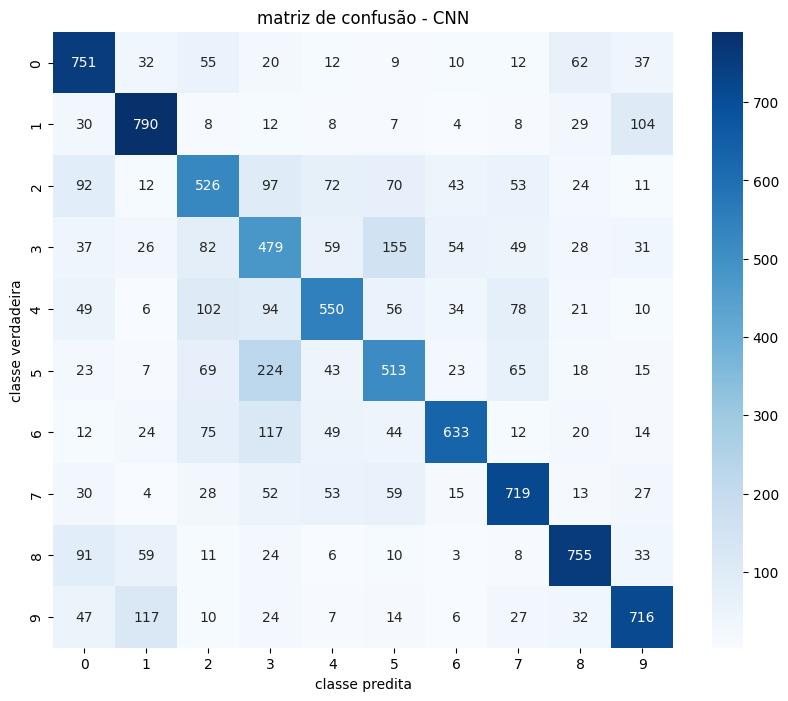

In [22]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("classe predita")
plt.ylabel("classe verdadeira")
plt.title("matriz de confusão - CNN")
plt.show()

A matriz de confusão da CNN mostra acertos bem mais concentrados na diagonal em comparação com a MLP, indicando melhor desempenho geral; classes como automóvel (2), caminhão (3), avião (5) e navio (8) tiveram melhora significativa, pois a CNN reduziu confusões que eram frequentes na MLP, enquanto classes como 0, 1, 6, 7, 8 e 9 também se destacaram com altos índices de acerto; essa superioridade ocorre porque CNNs conseguem extrair padrões locais (bordas, texturas, formas), construir representações hierárquicas e manter invariância espacial, o que permite distinguir melhor classes visualmente semelhantes, algo que a MLP não consegue já que trata cada pixel de forma independente.

### <font color='#2D9CDB'>Q22) Adicione camadas Dropout à CNN e treine novamente o modelo. Em seguida, plote as curvas de loss e accuracy para os conjuntos de treinamento e validação e compare os resultados com a CNN original. Com base nos gráficos obtidos, discuta o impacto do Dropout no overfitting e na capacidade de generalização da rede neural.</font>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.3654 - loss: 1.7316 - val_accuracy: 0.5154 - val_loss: 1.3735
Epoch 2/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.4918 - loss: 1.4160 - val_accuracy: 0.5831 - val_loss: 1.1973
Epoch 3/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5374 - loss: 1.2979 - val_accuracy: 0.6096 - val_loss: 1.1067
Epoch 4/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5655 - loss: 1.2223 - val_accuracy: 0.6307 - val_loss: 1.0659
Epoch 5/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5863 - loss: 1.1635 - val_accuracy: 0.6536 - val_loss: 1.0072
Epoch 6/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5988 - loss: 1.1289 - val_accuracy: 0.6615 - val_loss: 0.9828
Epoch 7/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6159 - loss: 1.0940 - val_accuracy: 0.6764 - val_loss: 0.9369
Epoch 8/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6257 - loss: 1.0565 -

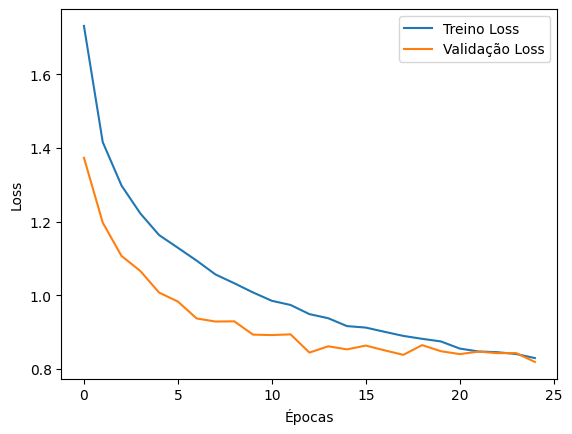

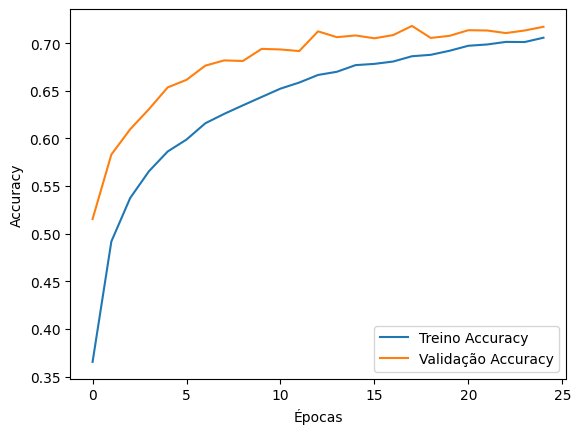

In [24]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=25,
    batch_size=32,
    validation_data=(x_val, y_val)
)

plt.plot(history.history['loss'], label='Treino Loss')
plt.plot(history.history['val_loss'], label='Validação Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Treino Accuracy')
plt.plot(history.history['val_accuracy'], label='Validação Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


O Dropout força a rede a não depender de combinações específicas de neurônios, tornando o modelo mais robusto e melhor em dados novos.

### <font color='#2D9CDB'>Q23) Com base em todos os resultados obtidos ao longo da atividade, compare as arquiteturas MLP e CNN para classificação de imagens. Em sua resposta, discuta diferenças relacionadas à preservação da estrutura espacial das imagens, quantidade de parâmetros treináveis, capacidade de generalização, desempenho obtido no CIFAR-10 e adequação de cada arquitetura para problemas de visão computacional.</font>

Comparando as arquiteturas MLP e CNN para classificação de imagens no CIFAR-10, observa-se que a MLP trata cada pixel de forma independente, sem preservar a estrutura espacial da imagem, o que limita sua capacidade de distinguir padrões visuais complexos e leva a maior confusão entre classes semelhantes; além disso, exige um número muito maior de parâmetros treináveis, tornando o modelo mais pesado e propenso a overfitting. Já a CNN explora convoluções e pooling para capturar padrões locais e hierárquicos, preservando a relação espacial entre pixels e reduzindo significativamente o número de parâmetros, o que melhora a eficiência e a capacidade de generalização. Nos resultados obtidos, a CNN apresentou desempenho superior, com maior acurácia e menor confusão entre classes visualmente próximas, mostrando-se mais adequada para problemas de visão computacional, enquanto a MLP pode ser útil em tarefas mais simples ou em dados tabulares, mas não é ideal para imagens complexas como as do CIFAR-10.